In [31]:
# Importy niezbędnych bibliotek
import os
import numpy as np
from medmnist import INFO
from medmnist.dataset import ChestMNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [32]:
def download_chestmnist():
    """Pobiera wszystkie podzbiory danych ChestMNIST i zapisuje je w folderze /data."""
    # Ustawienia
    output_folder = "data"
    subsets = ["train", "val", "test"]

    # Tworzenie folderu, jeśli nie istnieje
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    datasets = {}

    for subset in subsets:
        output_file = os.path.join(output_folder, f"chestmnist_{subset}_64x64.npz")

        # Pobieranie zestawu danych dla danego podzbioru
        print(f"Pobieranie zestawu danych ({subset})...")
        dataset = ChestMNIST(split=subset, download=True, size=64)

        # Zapisanie danych do pliku NPZ
        print(f"Zapisywanie danych do pliku {output_file}...")
        np.savez(output_file, images=dataset.imgs, labels=dataset.labels)
        datasets[subset] = dataset

        # Weryfikacja
        if os.path.exists(output_file):
            print(f"Dane ({subset}) zostały zapisane pomyślnie w pliku {output_file}.")
        else:
            print(f"Wystąpił problem podczas zapisu danych ({subset}).")

    return datasets

In [33]:
def load_chestmnist_from_files():
    """Wczytuje wszystkie podzbiory danych ChestMNIST z plików w folderze /data."""
    output_folder = "data"
    subsets = ["train", "val", "test"]
    datasets = {}

    for subset in subsets:
        output_file = os.path.join(output_folder, f"chestmnist_{subset}_64x64.npz")

        if not os.path.exists(output_file):
            raise FileNotFoundError(f"Plik {output_file} nie istnieje. Upewnij się, że dane zostały wcześniej zapisane.")

        print(f"Wczytywanie danych z pliku {output_file}...")
        data = np.load(output_file)

        class Dataset:
            imgs = data['images']
            labels = data['labels']

        datasets[subset] = Dataset()

    return datasets

In [34]:
# Wywołanie metod
try:
    datasets = load_chestmnist_from_files()
except FileNotFoundError:
    datasets = download_chestmnist()

Wczytywanie danych z pliku data\chestmnist_train_64x64.npz...
Wczytywanie danych z pliku data\chestmnist_val_64x64.npz...
Wczytywanie danych z pliku data\chestmnist_test_64x64.npz...


In [46]:
def translate_to_polish():
    """Zwraca słownik tłumaczeń klas chorób na język polski."""
    return {
        'atelectasis': 'niedodma',
        'cardiomegaly': 'kardiomegalia (powiększenie serca)',
        'effusion': 'wysięk',
        'infiltration': 'naciek',
        'mass': 'masa (guz)',
        'nodule': 'guzek',
        'pneumonia': 'zapalenie płuc',
        'pneumothorax': 'odma opłucnowa',
        'consolidation': 'konsolidacja',
        'edema': 'obrzęk',
        'emphysema': 'rozedma płuc',
        'fibrosis': 'włóknienie',
        'pleural': 'zgrubienie opłucnej',
        'hernia': 'przepuklina'
    }

def get_diagnosis(label):
    """Generuje diagnozę na podstawie etykiety."""
    translations = translate_to_polish()
    class_names = list(translations.values())
    
    # Jeśli wszystkie wartości w etykiecie to 0
    if all(label == 0):
        return "Zdrowy"
    
    # Pobranie nazw chorób na podstawie pozycji z wartością 1
    return ", ".join(
        [class_names[idx] for idx, value in enumerate(label) if value == 1]
    )

def display_images(dataset, amount=5):
    """Wyświetla określoną liczbę zdjęć z zestawu danych wraz z diagnozą."""
    print(f"Wyświetlanie pierwszych {amount} obrazów...")
    images = dataset.imgs[:amount]
    labels = dataset.labels[:amount]

    plt.figure(figsize=(15, 5))
    for i in range(amount):
        plt.subplot(1, amount, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')

        # Pobranie diagnozy na podstawie etykiety
        diagnosis = get_diagnosis(labels[i])
        
        plt.title(diagnosis, fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Podzbiór: train
Wyświetlanie pierwszych 5 obrazów...
[[133  24   2 ...  38  32   8]
 [113  16   1 ...  44  26   7]
 [111  15   1 ...  26  43  34]
 ...
 [121  15   0 ... 192 153  92]
 [127  16   0 ... 199 161 121]
 [136  23   2 ... 217 187 163]]
[[ 3  3  3 ...  1  1 12]
 [ 3  3  3 ...  1  1 12]
 [ 3  3  3 ...  1  0 11]
 ...
 [ 2  2  2 ...  1  1  5]
 [ 2  2  2 ...  1  1  7]
 [ 5  5  5 ...  3  4 15]]
[[246 237 230 ... 231 234 236]
 [166 107  88 ... 165 169 177]
 [ 46   4   1 ...  18  18  22]
 ...
 [ 34  28  28 ...  28  28  29]
 [ 34  28  28 ...  28  28  29]
 [ 34  28  28 ...  28  28  29]]
[[ 2  2  2 ... 58 64 18]
 [ 2  2  2 ... 37 40 12]
 [ 2  2  2 ... 35 36 11]
 ...
 [ 2  2  2 ... 48 49 14]
 [ 2  2  2 ... 52 50 14]
 [ 2  2  2 ... 51 51 15]]
[[ 18  16  16 ...  16  16  15]
 [ 17  16  16 ...  15  15  15]
 [ 17  16  16 ...  15  15  15]
 ...
 [ 77 107 184 ... 169 173 181]
 [ 67 109 184 ... 140 148 162]
 [ 87 133 200 ...  57  63  75]]


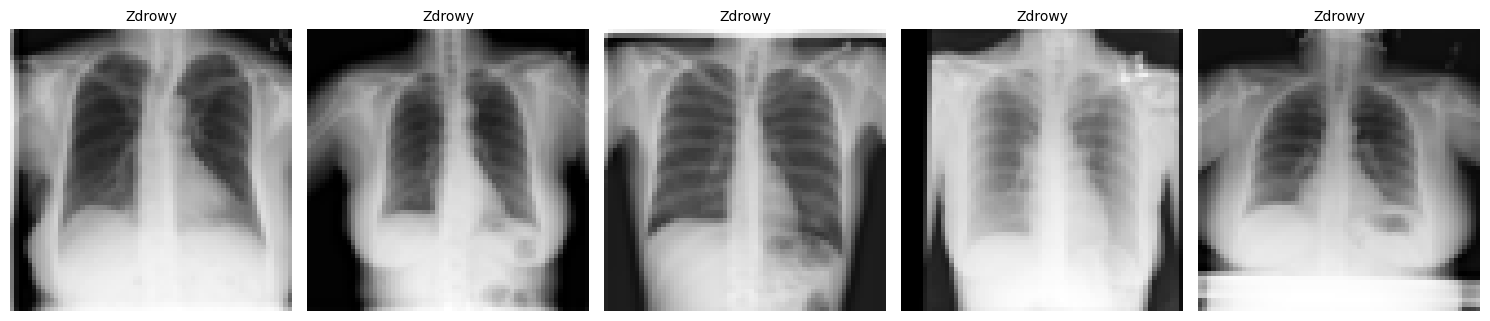


Podzbiór: val
Wyświetlanie pierwszych 5 obrazów...
[[8 0 1 ... 2 3 4]
 [7 0 0 ... 1 1 1]
 [7 0 0 ... 0 1 1]
 ...
 [1 1 1 ... 0 0 1]
 [1 1 1 ... 0 0 2]
 [8 7 7 ... 2 2 6]]
[[ 89  34  21 ...  28  30  33]
 [ 11   0   0 ...   0   0   0]
 [  6   0   0 ...   0   0   0]
 ...
 [  0   3  24 ... 117  75  39]
 [  0   2  23 ... 119  77  39]
 [  1   8  38 ... 133  94  56]]
[[ 31  31  30 ...  29  33  40]
 [ 31  31  29 ...  26  30  35]
 [ 31  29  27 ...  26  29  35]
 ...
 [ 26  26  24 ...  69 116 119]
 [ 27  26  25 ...  71 119 121]
 [ 27  27  25 ...  73 121 121]]
[[ 87  23  15 ...  39  39  27]
 [ 81  21  20 ...  55  60  51]
 [ 88  51  75 ... 104 112 110]
 ...
 [ 79  24  29 ...  20  20  20]
 [  4   1   2 ...   8   9   9]
 [  0   0   0 ...   0   0   0]]
[[ 0  3 13 ... 14 13 10]
 [ 0  3 13 ... 46 38 10]
 [ 0  3 12 ... 75 39  9]
 ...
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]]


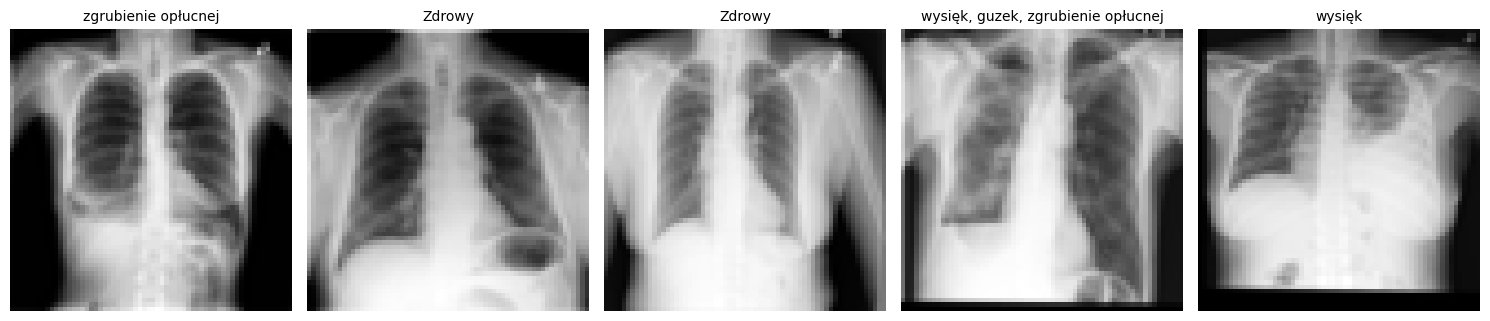


Podzbiór: test
Wyświetlanie pierwszych 5 obrazów...
[[15  0  0 ...  2  3  8]
 [ 6  0  0 ...  1  0  0]
 [ 6  0  0 ... 13  0  0]
 ...
 [ 0  0  1 ...  0  0  0]
 [ 0  0  1 ...  0  0  0]
 [ 0  0  6 ...  0  0  0]]
[[181  80   7 ...  21  21  20]
 [171  71   6 ...  21  21  20]
 [168  70   6 ...  21  21  20]
 ...
 [178  46   1 ...  16  20  20]
 [186  48   1 ...  16  20  20]
 [195  53   2 ...  18  21  21]]
[[ 16   1   0 ...  11  13  19]
 [  2   0   0 ...   0   0   0]
 [ 16   9  20 ...   0   0   0]
 ...
 [172 180 201 ...  75   8   0]
 [174 186 206 ...  55   2   1]
 [185 201 219 ...  45   1   4]]
[[ 77  72  71 ... 177 190 215]
 [  7   7   7 ...  28  37  90]
 [  9   9  10 ...   1   0  20]
 ...
 [ 17  16  16 ...   7   9  93]
 [ 17  16  16 ...   7  10  97]
 [ 17  17  17 ...   6   9 101]]
[[127  82  72 ... 176 184 192]
 [ 15   2   1 ...  36  40  44]
 [  8   3   4 ...   0   0   0]
 ...
 [ 13  13  13 ...  13  13  12]
 [ 13  13  13 ...  13  13  13]
 [ 13  13  13 ...  13  13  13]]


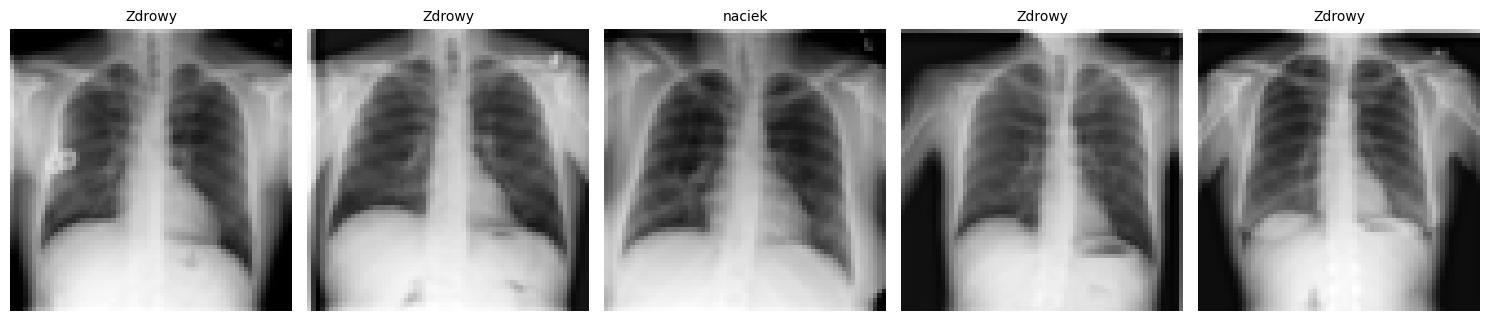

In [47]:
# Wyświetlanie po 5 obrazów z każdego podzbioru
def display_all_subsets(datasets, amount=5):
    for subset_name, dataset in datasets.items():
        print(f"\nPodzbiór: {subset_name}")
        display_images(dataset, amount=amount)

display_all_subsets(datasets, amount=5)